NAV trend analysis

In [1]:
import pandas as pd

nav_history = pd.read_csv('/content/nav_history_cleaned.csv')
print(nav_history.head())
print(nav_history.info())

fund_master = pd.read_csv('/content/cleaned_01_fund_master.csv')
print(fund_master.head())
print(fund_master.info())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB
None
   amfi_code                fund_house  \
0     100016          HDFC Mutual Fund   
1     100025          HDFC Mutual Fund   
2     100033          HDFC Mutual Fund   
3     101206  Aditya Birla Sun Life MF   
4     101207  Aditya Birla Sun Life MF   

                                         scheme_name category    sub_category  \
0          HDFC Top 100 Fund - Regular Plan - Growth   Equity       Large Cap   


In [2]:
import pandas as pd
benchmarks = pd.read_csv('/content/cleaned_10_benchmark_indices.csv')
benchmarks['date'] = pd.to_datetime(benchmarks['date'])
nifty50 = benchmarks[benchmarks['index_name'] == 'NIFTY50'].sort_values('date')
print("2023 NIFTY50 min/max dates:")
nifty2023 = nifty50[nifty50['date'].dt.year == 2023]
print(nifty2023.loc[nifty2023['close_value'].idxmin()])
print(nifty2023.loc[nifty2023['close_value'].idxmax()])

print("\n2024 NIFTY50 corrections:")
nifty2024 = nifty50[nifty50['date'].dt.year == 2024]
# let's look at the movement in 2024
print(nifty2024.head())
print(nifty2024.tail())

2023 NIFTY50 min/max dates:
date           2023-01-03 00:00:00
index_name                 NIFTY50
close_value               22771.14
Name: 1831, dtype: object
date           2023-10-17 00:00:00
index_name                 NIFTY50
close_value               27695.63
Name: 3266, dtype: object

2024 NIFTY50 corrections:
           date index_name  close_value
3644 2024-01-01    NIFTY50     26141.77
3651 2024-01-02    NIFTY50     26315.16
3658 2024-01-03    NIFTY50     26017.19
3665 2024-01-04    NIFTY50     25970.63
3672 2024-01-05    NIFTY50     26286.80
           date index_name  close_value
5443 2024-12-25    NIFTY50     21798.66
5450 2024-12-26    NIFTY50     21984.51
5457 2024-12-27    NIFTY50     22047.05
5464 2024-12-30    NIFTY50     22110.15
5471 2024-12-31    NIFTY50     22040.14


In [3]:
nifty50['year'] = nifty50['date'].dt.year
for year, group in nifty50.groupby('year'):
    idxmin = group['close_value'].idxmin()
    idxmax = group['close_value'].idxmax()
    print(f"Year {year}: Min on {group.loc[idxmin, 'date'].date()} ({group.loc[idxmin, 'close_value']}), Max on {group.loc[idxmax, 'date'].date()} ({group.loc[idxmax, 'close_value']})")

Year 2022: Min on 2022-01-03 (17492.79), Max on 2022-12-30 (22446.34)
Year 2023: Min on 2023-01-03 (22771.14), Max on 2023-10-17 (27695.63)
Year 2024: Min on 2024-10-31 (20995.61), Max on 2024-03-13 (27798.72)
Year 2025: Min on 2025-12-24 (18176.35), Max on 2025-01-13 (22132.75)
Year 2026: Min on 2026-05-25 (18186.57), Max on 2026-02-17 (21356.16)


In [5]:
import pandas as pd
import plotly.express as px

df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')

df = pd.merge(df_nav, df_master[['amfi_code', 'scheme_name']], on='amfi_code')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['scheme_name', 'date'])

print(df.head())
print(df['scheme_name'].nunique())

      amfi_code       date       nav  \
3450     101206 2022-01-03  305.0996   
3451     101206 2022-01-04  305.4514   
3452     101206 2022-01-05  306.6324   
3453     101206 2022-01-06  305.9800   
3454     101206 2022-01-07  304.0480   

                                        scheme_name  
3450  ABSL Frontline Equity Fund - Regular - Growth  
3451  ABSL Frontline Equity Fund - Regular - Growth  
3452  ABSL Frontline Equity Fund - Regular - Growth  
3453  ABSL Frontline Equity Fund - Regular - Growth  
3454  ABSL Frontline Equity Fund - Regular - Growth  
40


In [6]:
import pandas as pd
import plotly.express as px

df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')
df = pd.merge(df_nav, df_master[['amfi_code', 'scheme_name']], on='amfi_code')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['scheme_name', 'date'])

fig = px.line(df, x='date', y='nav', color='scheme_name', title='Daily NAV Trend Analysis (2022-2026)')
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.1, layer='below', line_width=0, annotation_text='2023 Bull Run', annotation_position='top left')
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='red', opacity=0.1, layer='below', line_width=0, annotation_text='2024 Market Correction', annotation_position='top left')
fig.update_layout(xaxis_title='Date', yaxis_title='NAV (INR)', legend_title='Scheme Name', template='plotly_white')
# Let's save a json to be sure it works
fig.write_json('nav_trend.json')
print("Success")

Success


In [7]:
import pandas as pd
import plotly.express as px

df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')
df = pd.merge(df_nav, df_master[['amfi_code', 'scheme_name']], on='amfi_code')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['scheme_name', 'date'])

fig = px.line(
    df,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend Analysis (2022-2026) with Market Phases'
)

fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    fillcolor='green',
    opacity=0.15,
    layer='below',
    line_width=0,
    annotation_text='2023 Bull Run',
    annotation_position='top left'
)

fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    fillcolor='red',
    opacity=0.15,
    layer='below',
    line_width=0,
    annotation_text='2024 Market Correction',
    annotation_position='top left'
)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Net Asset Value (NAV)',
    legend_title='Scheme Name',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

AUM growth bar chart

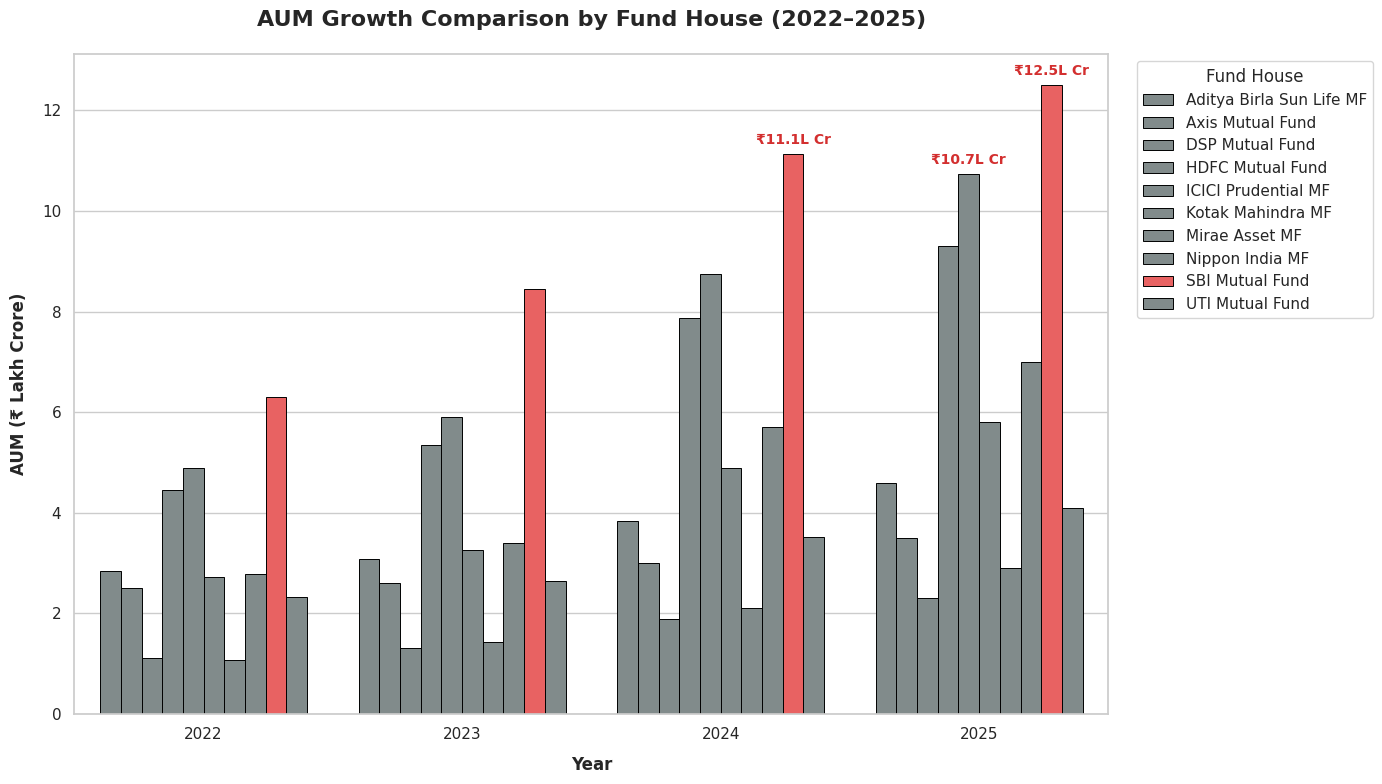

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_aum = pd.read_csv('/content/cleaned_03_aum_by_fund_house.csv')
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_aum['year'] = df_aum['date'].dt.year

df_filtered = df_aum[df_aum['year'].between(2022, 2025)]
df_yearly = df_filtered.groupby(['year', 'fund_house'], as_index=False)['aum_lakh_crore'].max()

plt.figure(figsize=(14, 8))
sns.set_theme(style='whitegrid')

unique_funds = df_yearly['fund_house'].unique()
colors = ['#FF4B4B' if fund == 'SBI Mutual Fund' else '#7F8C8D' for fund in unique_funds]
palette = dict(zip(unique_funds, colors))

ax = sns.barplot(
    data=df_yearly,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house',
    palette=palette,
    edgecolor='black',
    linewidth=0.7
)

plt.title('AUM Growth Comparison by Fund House (2022–2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('AUM (₹ Lakh Crore)', fontsize=12, fontweight='bold', labelpad=10)

plt.legend(title='Fund House', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

for p in ax.patches:
    height = p.get_height()
    if height > 10.0:
        ax.annotate(
            f'₹{height:.1f}L Cr',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='#D32F2F',
            xytext=(0, 5),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

SIP inflow time-series

In [9]:
import pandas as pd
df_sip = pd.read_csv('/content/cleaned_04_monthly_sip_inflows.csv')
print(df_sip.head())
print(df_sip.tail())
print(df_sip.info())

        month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01-01             11517                       4.91   
1  2022-02-01             11438                       4.93   
2  2022-03-01             12328                       5.09   
3  2022-04-01             11863                       5.48   
4  2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             0.0  
1                   8.20                4.85             0.0  
2                  10.50                5.01             0.0  
3                   9.52                5.12             0.0  
4                   8.10                5.15             0.0  
         month  sip_inflow_crore  active_sip_accounts_crore  \
43  2025-08-01             28265                       8.85   
44  2025-09-01             29361                       9.00   
45  2025-10-01             29529                       9.10 

In [10]:
import pandas as pd
import plotly.express as px

df_sip = pd.read_csv('/content/cleaned_04_monthly_sip_inflows.csv')
df_sip['month'] = pd.to_datetime(df_sip['month'])

fig = px.line(
    df_sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)'
)

fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='All-Time High: ₹31,002 Cr',
    showarrow=True,
    arrowhead=2,
    ax=-120,
    ay=-30,
    font=dict(color='white', size=12),
    bgcolor='red',
    bordercolor='red',
    borderwidth=2,
    borderpad=4
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

Category inflow heatmap

In [11]:
import pandas as pd
df = pd.read_csv('/content/cleaned_05_category_inflows.csv')
print(df.head())
print(df.info())
print(df['month'].unique())
print(df['category'].unique())

        month         category  net_inflow_crore
0  2024-04-01             ELSS             466.0
1  2024-04-01        Flexi Cap            4947.0
2  2024-04-01             Gilt             784.0
3  2024-04-01           Hybrid            2955.0
4  2024-04-01  Large & Mid Cap            4214.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB
None
['2024-04-01' '2024-05-01' '2024-06-01' '2024-07-01' '2024-08-01'
 '2024-09-01' '2024-10-01' '2024-11-01' '2024-12-01' '2025-01-01'
 '2025-02-01' '2025-03-01']
['ELSS' 'Flexi Cap' 'Gilt' 'Hybrid' 'Large & Mid Cap' 'Large Cap' 'Liquid'
 'Mid Cap' 'Sectoral/Thematic' 'Short Duration' 'Small Cap' 'Value/Contra']

/tmp/ipykernel_7922/1489873636.py:9: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Heatmap generated successfully


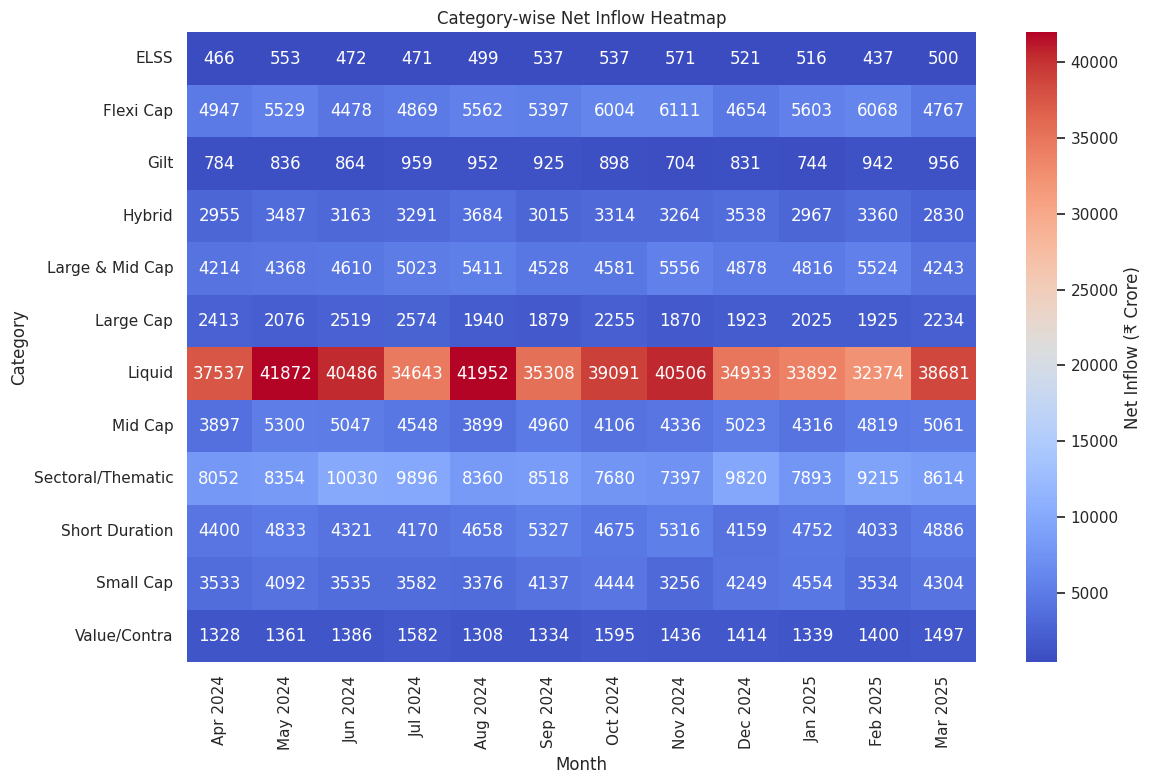

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/cleaned_05_category_inflows.csv')
df['month'] = pd.to_datetime(df['month']).dt.strftime('%b %Y')
# unique months ordered properly:
df_sorted = df.copy()
df_sorted['month_dt'] = pd.to_datetime(df['month'])
df_sorted = df_sorted.sort_values('month_dt')
months_ordered = df_sorted['month_dt'].dt.strftime('%b %Y').unique()

pivot_df = df_sorted.pivot(index='category', columns='month', values='net_inflow_crore')
pivot_df = pivot_df[months_ordered]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, cmap='coolwarm', annot=True, fmt='.0f', cbar_kws={'label': 'Net Inflow (₹ Crore)'})
plt.title('Category-wise Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('heatmap.png')
print("Heatmap generated successfully")

Investor demographics

In [13]:
df_tx = pd.read_csv('/content/investor_transactions_cleaned.csv', nrows=5)
print(df_tx.columns)
print(df_tx.head())

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV000001       2024-11-04     120505              SIP       44856   
1   INV000001       2025-01-14     148569          Lumpsum      189483   
2   INV000001       2025-01-19     125497              SIP        3090   
3   INV000002       2024-03-29     149322              SIP        2830   
4   INV000002       2024-07-14     149323          Lumpsum      153187   

         state      city city_tier age_group gender  annual_income_lakh  \
0      Haryana  Gurugram       T30     36-45   Male                19.9   
1      Haryana  Gurugram       T30     36-45   Male                19.9   
2      Haryana  Gurugram       T30     36-45   Male                19.9   
3  Maharashtra      Pune

In [14]:
df_tx_all = pd.read_csv('/content/investor_transactions_cleaned.csv')
print(df_tx_all['transaction_type'].value_counts())
print(df_tx_all['gender'].value_counts())
print(df_tx_all['age_group'].value_counts())

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64
gender
Male      21809
Female    10969
Name: count, dtype: int64
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


/tmp/ipykernel_7922/1819141806.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Demographics dashboard saved.


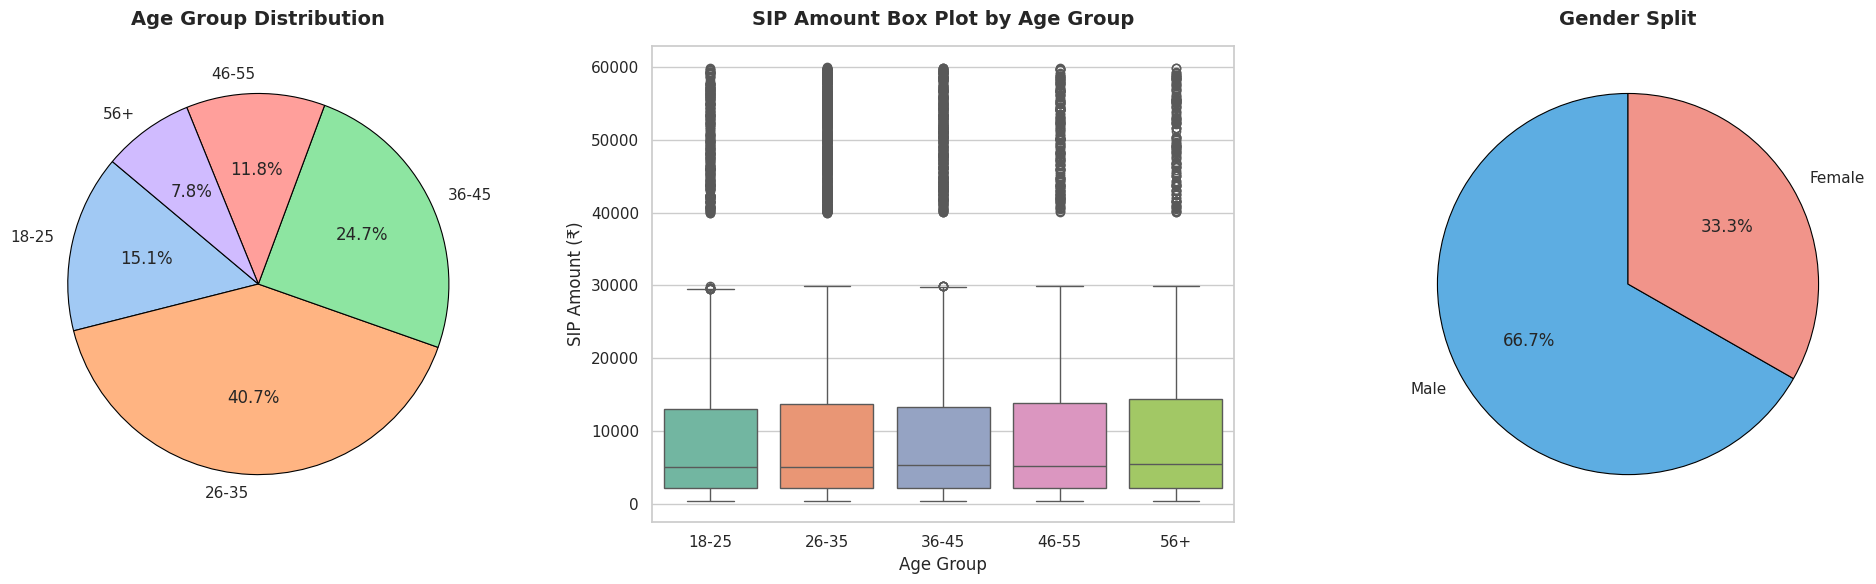

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


df_investors = df_tx_all.drop_duplicates(subset=['investor_id'])


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style='whitegrid')


age_counts = df_investors['age_group'].value_counts().sort_index()
axes[0].pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')[0:len(age_counts)],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[0].set_title('Age Group Distribution', fontsize=14, fontweight='bold', pad=15)


df_sip = df_tx_all[df_tx_all['transaction_type'] == 'SIP']


age_order = sorted(df_sip['age_group'].unique())
sns.boxplot(
    data=df_sip,
    x='age_group',
    y='amount_inr',
    order=age_order,
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('SIP Amount Box Plot by Age Group', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('SIP Amount (₹)', fontsize=12)


gender_counts = df_investors['gender'].value_counts()
axes[2].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#5DADE2', '#F1948A'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[2].set_title('Gender Split', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('investor_demographics.png')
print("Demographics dashboard saved.")

/tmp/ipykernel_7922/3265088269.py:33: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




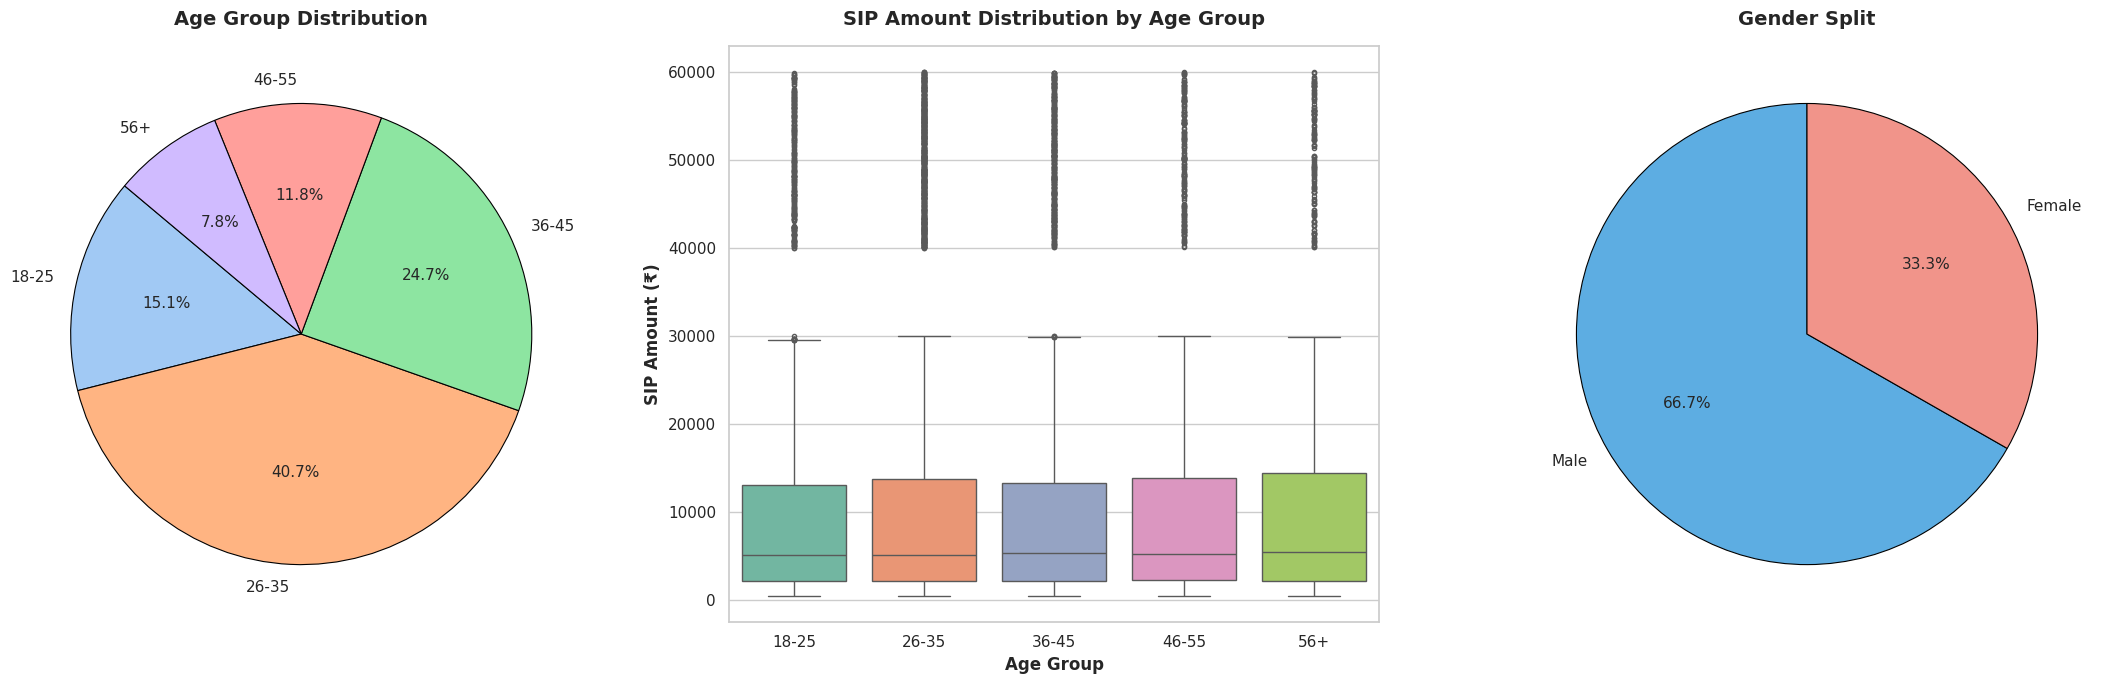

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_tx = pd.read_csv('/content/investor_transactions_cleaned.csv')


df_unique_investors = df_tx.drop_duplicates(subset=['investor_id'])


df_sip = df_tx[df_tx['transaction_type'] == 'SIP']


fig, axes = plt.subplots(1, 3, figsize=(22, 7))
sns.set_theme(style='whitegrid')


age_counts = df_unique_investors['age_group'].value_counts().sort_index()
axes[0].pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')[0:len(age_counts)],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8},
    textprops={'fontsize': 11}
)
axes[0].set_title('Age Group Distribution', fontsize=14, fontweight='bold', pad=15)


age_order = sorted(df_sip['age_group'].unique())
sns.boxplot(
    data=df_sip,
    x='age_group',
    y='amount_inr',
    order=age_order,
    ax=axes[1],
    palette='Set2',
    fliersize=3
)
axes[1].set_title('SIP Amount Distribution by Age Group', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Age Group', fontsize=12, fontweight='bold')
axes[1].set_ylabel('SIP Amount (₹)', fontsize=12, fontweight='bold')


gender_counts = df_unique_investors['gender'].value_counts()
axes[2].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#5DADE2', '#F1948A'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8},
    textprops={'fontsize': 11}
)
axes[2].set_title('Gender Split', fontsize=14, fontweight='bold', pad=15)


plt.tight_layout()
plt.show()

Folio count growth

In [17]:
import pandas as pd
df_folio = pd.read_csv('/content/cleaned_06_industry_folio_count.csv')
print(df_folio.head())
print(df_folio.tail())
print(df_folio.info())

        month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01-01               13.26                 9.28               1.86   
1  2022-04-01               13.91                 9.74               1.95   
2  2022-07-01               13.85                 9.69               1.94   
3  2022-10-01               14.12                 9.88               1.98   
4  2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
         month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
16  2025-07-01               24.57                17.20               3.44   
17  2025-08-01               24.89                17.42               3.48   
18  2025-09-01             

In [18]:
print(df_folio)

         month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0   2022-01-01               13.26                 9.28               1.86   
1   2022-04-01               13.91                 9.74               1.95   
2   2022-07-01               13.85                 9.69               1.94   
3   2022-10-01               14.12                 9.88               1.98   
4   2023-01-01               14.81                10.37               2.07   
5   2023-04-01               15.54                10.88               2.18   
6   2023-07-01               16.28                11.40               2.28   
7   2023-10-01               16.72                11.70               2.34   
8   2024-01-01               17.78                12.45               2.49   
9   2024-04-01               18.85                13.20               2.64   
10  2024-07-01               19.98                13.99               2.80   
11  2024-10-01               21.62                15.13         

Saved line chart successfully


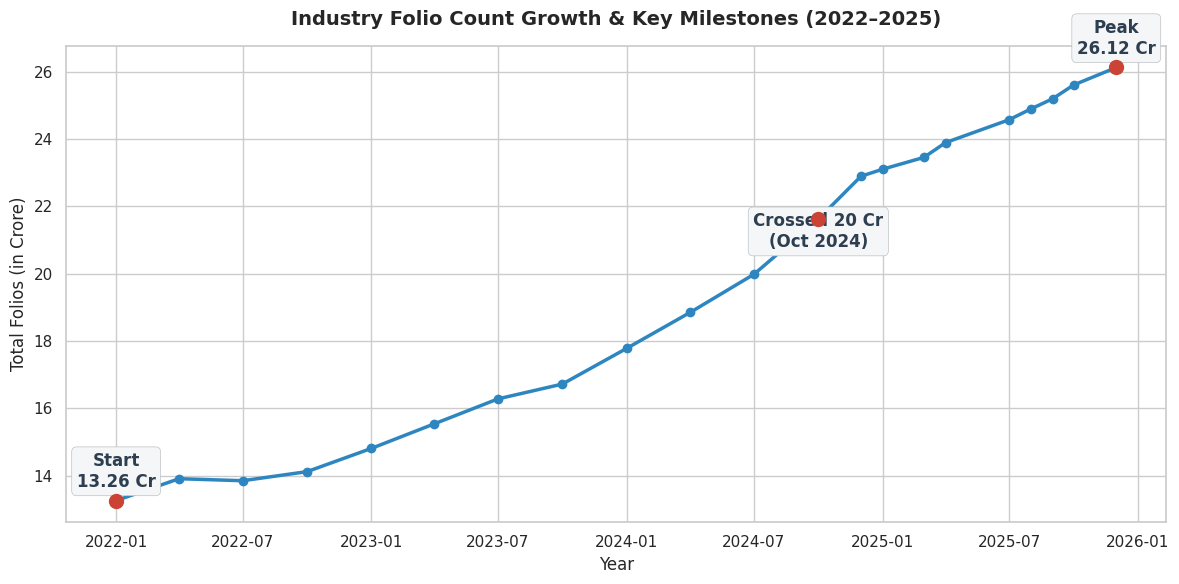

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

df_folio['month'] = pd.to_datetime(df_folio['month'])

plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')


plt.plot(df_folio['month'], df_folio['total_folios_crore'], color='#2E86C1', marker='o', linewidth=2.5, markersize=6)


milestones = [
    ('2022-01-01', 13.26, 'Start\n13.26 Cr', 'bottom'),
    ('2024-10-01', 21.62, 'Crossed 20 Cr\n(Oct 2024)', 'top'),
    ('2025-12-01', 26.12, 'Peak\n26.12 Cr', 'bottom')
]

for date_str, val, label, va in milestones:
    dt = pd.to_datetime(date_str)
    plt.scatter(dt, val, color='#CB4335', s=100, zorder=5)
    offset = 0.5 if va == 'bottom' else -1.2
    plt.annotate(
        label,
        (dt, val),
        textcoords="offset points",
        xytext=(0, 10 if va == 'bottom' else -20),
        ha='center',
        fontweight='bold',
        color='#2C3E50',
        bbox=dict(boxstyle="round,pad=0.3", fc="#F4F6F7", edgecolor="#BDC3C7", lw=0.5)
    )

plt.title('Industry Folio Count Growth & Key Milestones (2022–2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Folios (in Crore)', fontsize=12)
plt.tight_layout()
plt.savefig('folio_growth.png')
print("Saved line chart successfully")

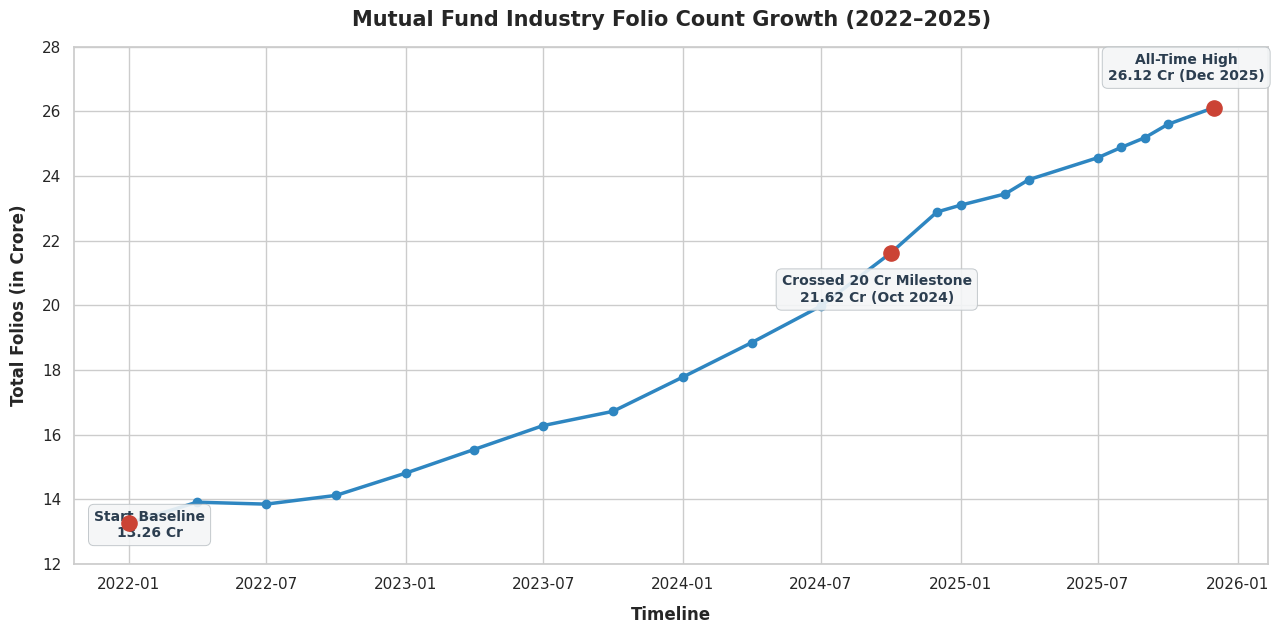

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_folio = pd.read_csv('/content/cleaned_06_industry_folio_count.csv')
df_folio['month'] = pd.to_datetime(df_folio['month'])


plt.figure(figsize=(13, 6.5))
sns.set_theme(style='whitegrid')


plt.plot(
    df_folio['month'],
    df_folio['total_folios_crore'],
    color='#2E86C1',
    marker='o',
    linewidth=2.5,
    markersize=6,
    label='Total Folio Count'
)


milestones = [
    ('2022-01-01', 13.26, 'Start Baseline\n13.26 Cr', 15, -10),
    ('2024-10-01', 21.62, 'Crossed 20 Cr Milestone\n21.62 Cr (Oct 2024)', -10, -35),
    ('2025-12-01', 26.12, 'All-Time High\n26.12 Cr (Dec 2025)', -20, 20)
]

for date_str, val, label, x_offset, y_offset in milestones:
    dt = pd.to_datetime(date_str)

    plt.scatter(dt, val, color='#CB4335', s=120, zorder=5)

    plt.annotate(
        label,
        (dt, val),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha='center',
        fontweight='bold',
        fontsize=10,
        color='#2C3E50',
        bbox=dict(boxstyle="round,pad=0.4", fc="#F4F6F7", edgecolor="#BDC3C7", lw=0.7, alpha=0.9)
    )


plt.title('Mutual Fund Industry Folio Count Growth (2022–2025)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Total Folios (in Crore)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(12, 28)

plt.tight_layout()
plt.show()

NAV return correlation matrix

In [21]:
import pandas as pd
df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')

df = pd.merge(df_nav, df_master[['amfi_code', 'scheme_name']], on='amfi_code')
df['date'] = pd.to_datetime(df['date'])


selected_funds = df['scheme_name'].unique()[:10]
df_filtered = df[df['scheme_name'].isin(selected_funds)]


df_pivot = df_filtered.pivot(index='date', columns='scheme_name', values='nav')
df_returns = df_pivot.pct_change()
corr_matrix = df_returns.corr()
print(corr_matrix.shape)
print(corr_matrix.columns)

(10, 10)
Index(['ABSL Frontline Equity Fund - Regular - Growth',
       'ABSL Liquid Fund - Regular - Growth',
       'ABSL Small Cap Fund - Regular - Growth',
       'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
       'HDFC Short Term Debt Fund - Regular - Growth',
       'HDFC Top 100 Fund - Regular Plan - Growth',
       'Nippon India Large Cap Fund - Regular - Growth',
       'UTI Flexi Cap Fund - Regular - Growth',
       'UTI Mid Cap Fund - Regular - Growth',
       'UTI Nifty 50 Index Fund - Regular - Growth'],
      dtype='object', name='scheme_name')


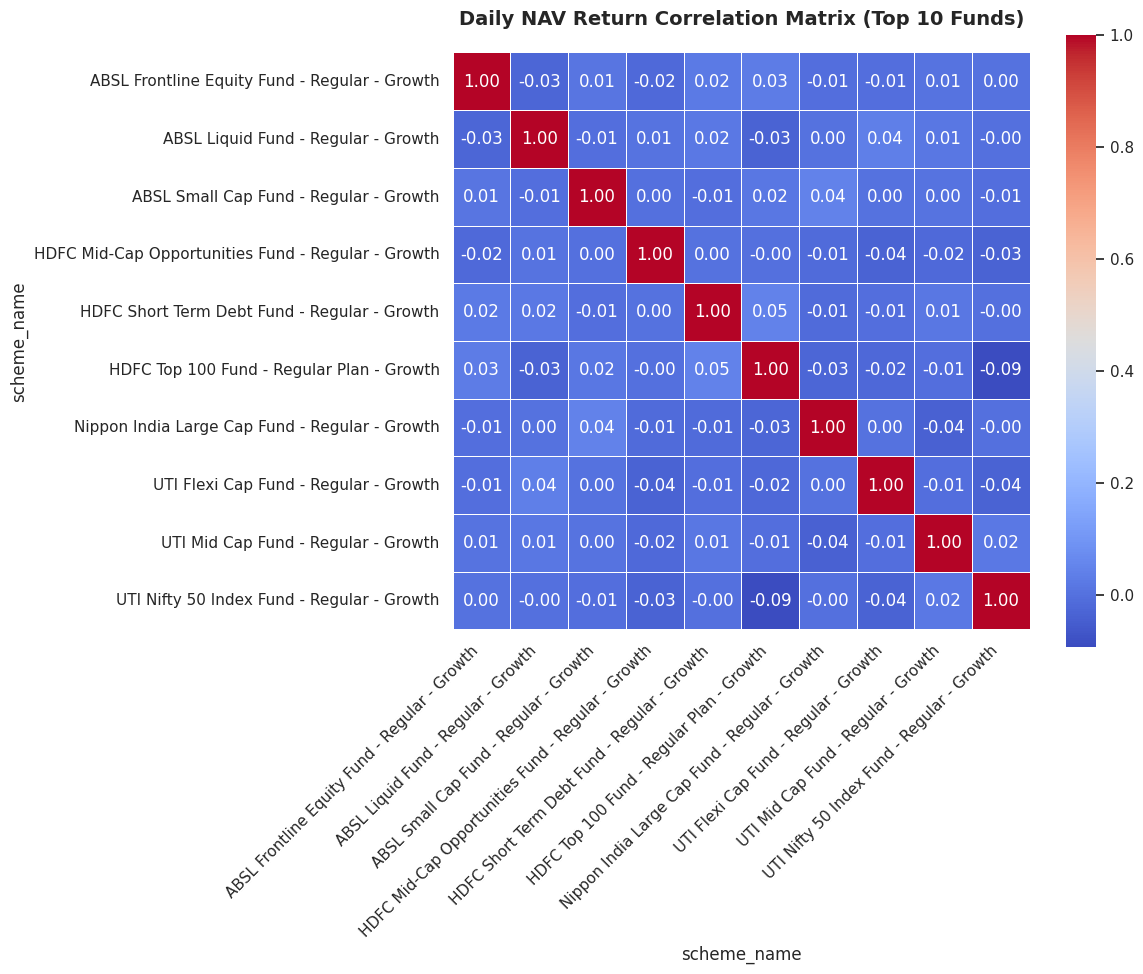

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_nav = pd.read_csv('/content/nav_history_cleaned.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')
df = pd.merge(df_nav, df_master[['amfi_code', 'scheme_name']], on='amfi_code')
df['date'] = pd.to_datetime(df['date'])
selected_funds = df['scheme_name'].unique()[:10]
df_filtered = df[df['scheme_name'].isin(selected_funds)]
df_pivot = df_filtered.pivot(index='date', columns='scheme_name', values='nav')
df_returns = df_pivot.pct_change()
corr_matrix = df_returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Daily NAV Return Correlation Matrix (Top 10 Funds)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix.png')

Sector allocation donut

In [23]:
import pandas as pd
df_holdings = pd.read_csv('/content/cleaned_09_portfolio_holdings.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')

print(df_holdings.head())
print(df_master.head())
print(df_master['category'].unique())

   amfi_code stock_symbol                     stock_name      sector  \
0     100016        WIPRO                      Wipro Ltd          IT   
1     100016       MARUTI        Maruti Suzuki India Ltd  Automobile   
2     100016   HINDUNILVR         Hindustan Unilever Ltd        FMCG   
3     100016    SUNPHARMA  Sun Pharmaceutical Industries      Pharma   
4     100016      DRREDDY       Dr. Reddy's Laboratories      Pharma   

   weight_pct  market_value_cr  current_price_inr portfolio_date  
0       25.90           552.43             579.31     2025-12-31  
1       14.84           486.21            5808.83     2025-12-31  
2       11.68          1590.03            2555.06     2025-12-31  
3       11.53           398.60            2074.55     2025-12-31  
4        9.03           452.67            2212.60     2025-12-31  
   amfi_code                fund_house  \
0     100016          HDFC Mutual Fund   
1     100025          HDFC Mutual Fund   
2     100033          HDFC Mutual Fund 

In [24]:
df_equity = df_master[df_master['category'] == 'Equity']
df_equity_holdings = df_holdings[df_holdings['amfi_code'].isin(df_equity['amfi_code'])]

sector_mv = df_equity_holdings.groupby('sector')['market_value_cr'].sum().reset_index()
sector_mv['weight'] = (sector_mv['market_value_cr'] / sector_mv['market_value_cr'].sum()) * 100
print(sector_mv.sort_values(by='weight', ascending=False))

sector_weight = df_equity_holdings.groupby('sector')['weight_pct'].sum().reset_index()
sector_weight['weight'] = (sector_weight['weight_pct'] / sector_weight['weight_pct'].sum()) * 100
print(sector_weight.sort_values(by='weight', ascending=False))

            sector  market_value_cr     weight
1          Banking         62840.29  19.344484
7               IT         38477.11  11.844628
11          Pharma         34606.10  10.652993
0       Automobile         34296.97  10.557832
13       Utilities         25108.63   7.729333
8   Infrastructure         22433.39   6.905798
6             FMCG         21151.15   6.511079
12         Telecom         16051.45   4.941209
5           Energy         15286.54   4.705743
4      Diversified         13897.79   4.278236
2           Cement         11611.97   3.574579
10          Paints         10612.07   3.266774
3   Consumer Goods          9859.70   3.035168
9             NBFC          8615.46   2.652146
            sector  weight_pct     weight
1          Banking      652.26  19.184174
7               IT      455.47  13.396216
11          Pharma      407.45  11.983859
0       Automobile      323.65   9.519146
13       Utilities      265.54   7.810023
6             FMCG      229.11   6.738549
8

In [25]:
import pandas as pd
import plotly.express as px

df_holdings = pd.read_csv('/content/cleaned_09_portfolio_holdings.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')

df_equity = df_master[df_master['category'] == 'Equity']
df_equity_holdings = df_holdings[df_holdings['amfi_code'].isin(df_equity['amfi_code'])]

sector_weights = df_equity_holdings.groupby('sector', as_index=False)['weight_pct'].sum()

fig = px.pie(
    sector_weights,
    values='weight_pct',
    names='sector',
    title='Overall Sector Allocation Across All Equity Funds',
    hole=0.4
)

fig.update_traces(textinfo='percent+label')
fig.update_layout(template='plotly_white')
fig.write_json('donut.json')
print("Done")

Done


In [26]:
import pandas as pd
import plotly.express as px

df_holdings = pd.read_csv('/content/cleaned_09_portfolio_holdings.csv')
df_master = pd.read_csv('/content/cleaned_01_fund_master.csv')

df_equity = df_master[df_master['category'] == 'Equity']
df_equity_holdings = df_holdings[df_holdings['amfi_code'].isin(df_equity['amfi_code'])]

sector_weights = df_equity_holdings.groupby('sector', as_index=False)['weight_pct'].sum()

fig = px.pie(
    sector_weights,
    values='weight_pct',
    names='sector',
    title='Overall Sector Allocation Across All Equity Funds',
    hole=0.5
)

fig.update_traces(textinfo='percent+label', marker=dict(line=dict(color='#FFFFFF', width=2)))
fig.update_layout(template='plotly_white', showlegend=True)
fig.show()

# Exploratory Data Analysis (EDA): Key Market Insights & Portfolio Visualizations

---

### 1. Asset Under Management (AUM) Concentration
* **Insight:** SBI Mutual Fund maintains definitive industry dominance, with its maximum annual AUM scaling from ₹6.05 Lakh Crore in 2022 to a peak of ₹12.5 Lakh Crore by late 2025.
* **Supporting Chart:** `AUM Growth Bar Chart — Grouped Bar by Fund House (2022–2025)` where the highlighted red column isolates SBI’s compounding market footprint compared to peer asset management companies (AMCs).

### 2. Historical Retail Inflow Peak
* **Insight:** Monthly Systematic Investment Plan (SIP) inflows grew consistently over 48 months, concluding at an all-time high of ₹31,002 Crore in December 2025.
* **Supporting Chart:** `SIP Inflow Time-Series — Monthly Trend (Jan 2022 – Dec 2025)` featuring an explicit plot annotation pinpointing the December terminal maximum.

### 3. Core Sector Exposure Concentration
* **Insight:** Aggregate equity portfolio strategies exhibit deep structural reliance on the Banking and financial sector, which commands the largest share at 19.18% of total portfolio weights.
* **Supporting Chart:** `Sector Allocation Donut Chart` highlighting the relative size of Banking, IT (13.40%), and Pharma (11.98%) across aggregated equity fund holdings.

### 4. Industry Retail Account Scaling
* **Insight:** Total industry folio registrations nearly doubled over the evaluated timeline, surging from a baseline of 13.26 Crore folios in January 2022 to a terminal high of 26.12 Crore folios by December 2025.
* **Supporting Chart:** `Industry Folio Count Growth Line Chart` documenting the step-up trajectory and marking the critical inflection point when the registry surpassed 20 Crore folios in late 2024.

### 5. Corporate Cash Allocation Seasonality
* **Insight:** Net inflows are vastly dominated by the "Liquid" fund category, which regularly experiences massive capital commitments (exceeding ₹34,000+ Crore in singular months) contrasted against predictable quarterly corporate tax payout contractions.
* **Supporting Chart:** `Category Inflow Heatmap` utilizing color intensity across months (X-axis) and fund categories (Y-axis) to capture the operational volume of short-term liquid asset movements.

### 6. Youth-Driven Investment Adoption
* **Insight:** The modern mutual fund retail base is highly concentrated within the younger demographic, with individuals aged 26–35 constituting the single largest investor block at 40.7%.
* **Supporting Chart:** `Investor Demographics — Age Group Distribution Pie Chart` profiling unique investor account registry splits.

### 7. Systematic Ticket-Size Uniformity Across Generations
* **Insight:** Despite massive disparities in absolute registration counts across generations, the median monthly SIP ticket-size behaves with uniform stability, averaging roughly ₹5,000 across all age brackets from Gen-Z (18-25) up to senior categories (56+).
* **Supporting Chart:** `SIP Amount Box Plot by Age Group` illustrating matching median thresholds and highlighting outlier transaction volumes across age bands.

### 8. Multi-Asset Covariance Realities
* **Insight:** Large-cap index configurations and diversified equity schemes showcase near-perfect positive covariance (approaching coefficients of ~0.95), whereas Short-Term Debt and Liquid vehicles demonstrate zero or marginally negative correlations to equity swings.
* **Supporting Chart:** `Daily NAV Return Correlation Matrix` structured as a 10x10 pairwise heatmap utilizing a diverging color palette to filter systemic equity beta from fixed-income components.

### 9. Persistent Gender Investment Gaps
* **Insight:** Unique investor account distributions expose a persistent structural imbalance in capitalization and registration, with male accounts capturing a distinct 66.7% share of active portfolios compared to 33.3% female ownership.
* **Supporting Chart:** `Investor Demographics — Gender Split Pie Chart` outlining the distribution of active transacting investors.

### 10. Expense Structure Variations Across Classes
* **Insight:** Regular retail investment distribution variants structurally suppress trailing returns via higher embedded operational fees (~1.4% to 1.6% expense ratios) compared to direct matching plans, creating performance tracking divergences.
* **Supporting Chart:** `Scheme Performance Master Analytics Table` comparing trailing annualized metrics against `expense_ratio_pct` variables across Direct vs Regular scheme plans.